<a href="https://colab.research.google.com/github/DrStephPowers/MGMT-in-Python/blob/main/QualityPOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

Libraries needed for import

In [ ]:
import pandas as pd
import numpy as np

Link to your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import dataset (the sample code below assumes a folder in Google Drive called Datasets - change based on where you put your file)

In [ ]:
apple = pd.read_csv('/content/drive/MyDrive/Datasets/apple.csv')

In [ ]:
apple.head()

,id,variety,weight_g,brix_sugar,firmness_N,diameter_mm,defect
0,1,Fuji,113.8,14.38,61.7,73.7,Scab
1,2,Fuji,208.2,15.43,58.3,78.8,Bruising
2,3,Fuji,198.5,15.63,63.5,79.5,Rot
3,4,Fuji,163.1,14.74,81.5,75.6,Stem puncture
4,5,Fuji,187.3,13.52,56.8,69.5,Bruising


### Histogram

Use describe to better understand the range and distribution of data for setting the bins on the histogram

In [ ]:
apple.describe()

,id,weight_g,brix_sugar,firmness_N,diameter_mm
count,320.000000,320.000000,320.000000,320.000000,320.000000
mean,160.500000,174.433125,12.481844,63.830313,71.902813
std,92.520268,25.295163,2.799759,20.727907,6.450649
min,1.000000,104.900000,3.310000,29.800000,55.400000
25%,80.750000,158.900000,11.040000,52.275000,67.975000
50%,160.500000,172.850000,12.835000,60.000000,71.850000
75%,240.250000,189.675000,14.560000,71.400000,76.125000
max,320.000000,272.400000,19.530000,219.100000,89.400000


Set the bins, such as 50 up to 55, 55 up to 60...

In [ ]:
bins = [50,55,60,65,70,75,80]

Library for creating graphs

In [ ]:
import matplotlib.pyplot as plt

Creating the histogram

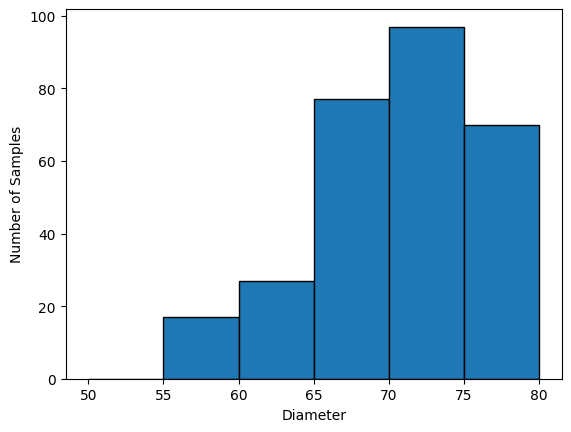

In [ ]:
plt.hist(apple["diameter_mm"], bins, edgecolor="black")
plt.xlabel("Diameter")
plt.ylabel("Number of Samples")
plt.show()

Create a histogram for brix_sugar

### Pareto Chart

Count the number of each type of defect and make it a table with rows.

In [ ]:
defect = apple["defect"].value_counts().reset_index()

Show the table

In [ ]:
defect

,defect,count
0,No defect,95
1,Bruising,65
2,Russeting,45
3,Scab,42
4,Stem puncture,31
5,Lenticel breakdown,24
6,Rot,18


Drop the row (in index 0) that contains no defects. Use reset_index() to start the row counting over again from 0 (Python counts from 0).

In [ ]:
defect = defect.drop([0]).reset_index()
defect

,index,defect,count
0,1,Bruising,65
1,2,Russeting,45
2,3,Scab,42
3,4,Stem puncture,31
4,5,Lenticel breakdown,24
5,6,Rot,18


Sort by most common defect.

In [ ]:
df = defect.sort_values(by='count', ascending=False)

Calculate the cumulative percentage and round to 2 decimal places

In [ ]:
df['cum_perc'] = round(df['count'].cumsum()/df['count'].sum()*100,2)

Show new table

In [ ]:
df

,index,defect,count,cum_perc
0,1,Bruising,65,28.89
1,2,Russeting,45,48.89
2,3,Scab,42,67.56
3,4,Stem puncture,31,81.33
4,5,Lenticel breakdown,24,92.00
5,6,Rot,18,100.00


Plot Pareto chart. First plot is the column chart. Second plot is the line chart.

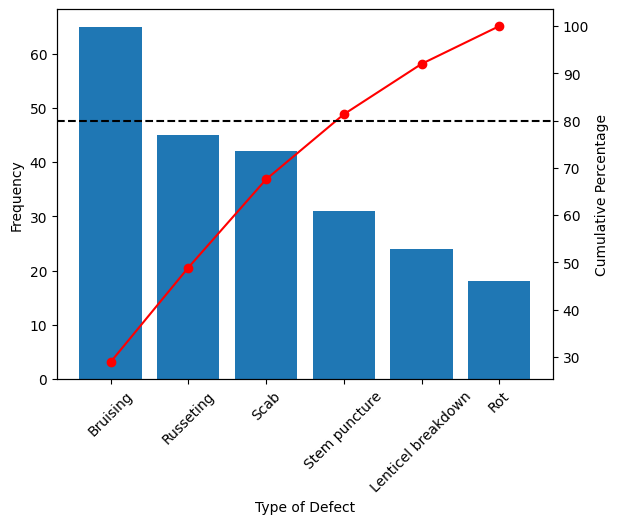

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.bar(df.index, df['count'])
ax.set_xlabel("Type of Defect")
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Frequency")

ax2 = ax.twinx()
ax2.plot(df['defect'], df["cum_perc"], marker= "o", color="red")
ax2.axhline(80, color="black", linestyle="dashed")
ax2.set_ylabel("Cumulative Percentage")
plt.show()

Use the ketchup.csv file to create a Pareto chart for the ketchup manufacturing defects. What issues should be tackled first?
1. Import the dataset and call it ketchup
2. Use ketchup.head() to check your table
3. Use ketchup.describe() and plt.hist() if you want to build a histogram
4. Use value_counts() to create a cross tabulation table (or pivot table) to summarize the type of defects
5. Calculate the cumulative percentage
6. Plot the two charts on top of each other

### Outlier Model (DBSCAN)

Import libraries for DBSCAN

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

Drop the variables you don't care about. DBSCAN requires interval/ratio data.

In [ ]:
apple2 = apple.drop(['id', 'variety', 'defect'], axis=1)

Show the top of the new table

In [ ]:
apple2.head()

,weight_g,brix_sugar,firmness_N,diameter_mm
0,113.8,14.38,61.7,73.7
1,208.2,15.43,58.3,78.8
2,198.5,15.63,63.5,79.5
3,163.1,14.74,81.5,75.6
4,187.3,13.52,56.8,69.5


Specify the number of variables used

In [ ]:
var = 4 # number of variables

Standardize the variables so that a variable with a larger measurement scale does not dominate the model just because of its scale.

In [ ]:
x = StandardScaler().fit_transform(apple2)

Use the classification K-Nearest Neighbors (supervised learning - AI) to determine how far away data points should be and still considered part of the same cluster.

In [ ]:
KNN = NearestNeighbors(n_neighbors=2*var)
neighbors = KNN.fit(x)
distances, indices = neighbors.kneighbors(x)

In [ ]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]

Change the upper bound of the y-axis to better see the curve in the data. The y-value at the bend in the plot, is the value used for eps in your cluster model.

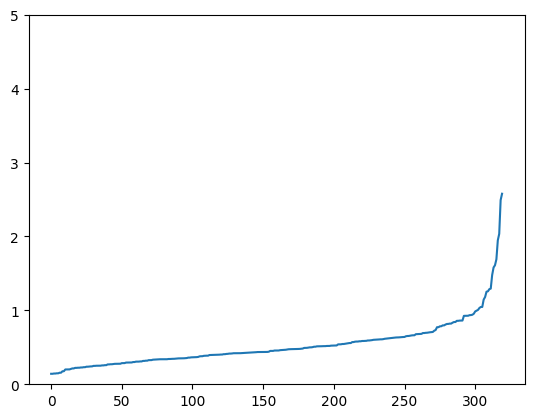

In [ ]:
plt.plot(distances)
plt.ylim(0, 5)
plt.show()

Use DBSCAN, a cluster alogorithm (unsupervised learning - AI) to give the datapoints labels. DBSCAN gives 2 labels: 0 for part of the cluster and -1 for an anomaly. Change the eps to match the y-value from the bend in the curve above.



In [ ]:
dbs = DBSCAN(eps=1, min_samples=2*var)
dbs.fit(x)
cl = dbs.labels_
cl

array([-1,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

Libraries for creating a scatterplot

In [ ]:
from seaborn import scatterplot
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['lines.markersize'] = 10

Creating the scatterplot. Select two variables (here it is brix_sugar and firmness_N) and plot where the color hue is determined by the cluster labels (cl).

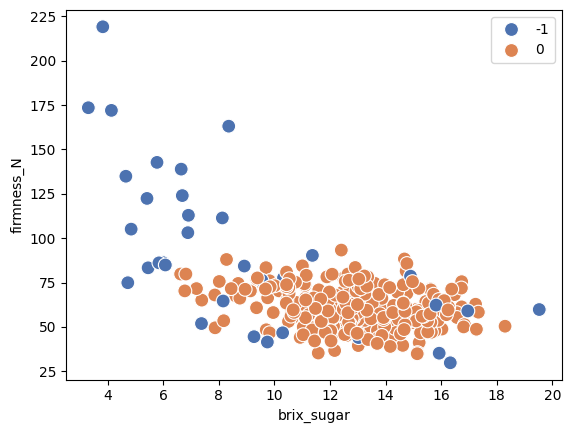

In [ ]:
scatterplot(x=apple2['brix_sugar'],y=apple2['firmness_N'], hue=cl, palette="deep")
plt.xlabel('brix_sugar')
plt.ylabel('firmness_N')
plt.show()

Pick two other variables, since what makes the apple an outlier may be another variable than what is shown in the scatterplot. That is why you see blue in the middle of the orange cluster.

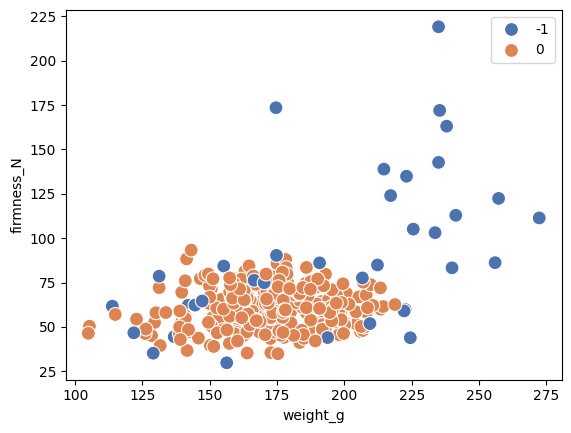

In [ ]:
scatterplot(x=apple2['weight_g'],y=apple2['firmness_N'], hue=cl, palette="deep")
plt.xlabel('weight_g')
plt.ylabel('firmness_N')
plt.show()

Perform DSBCAN with the ketchup data
1. Import the dataset and call it ketchup (if you didn't do it above)
2. Use ketchup.head() to check your table (if you didn't do it in the pareto section)
3. Drop the variables you don't care about and give the smaller table a different name
4. Check your new table with ketchup2.head(), if you called your new table ketchup2
5. Determine the number of eps using KNN
6. Perform a DBSCAN to get the cluster labels
7. Plot the cluster labels on a scatterplot to see the outliers